# ĐỀ TÀI #9: PHÂN TÍCH DISCOUNT CANNIBALIZATION (ĂN MÒN DOANH THU)
## Mục tiêu: Phân tích sự ảnh hưởng của Promo lên nhóm khách hàng cũ (Returning)

### Framework: D-Di-P-Pr (Descriptive-Diagnostic-Predictive-Prescriptive)

**Mục tiêu:**
- Đo lường mức độ "ăn mòn": Bao nhiêu % doanh thu khuyến mãi thực chất đến từ khách hàng sẵn sàng mua full price?
- Kiểm chứng Hypothesis: Promo đang là công cụ Retention bị động thay vì Acquisition.
- **Pain:** Chi phí Discount $X/năm nhưng không rõ bao nhiêu % là lãng phí cho khách "vốn dĩ sẽ mua".
- **Insight:** Promo đại trà không thu hút khách mới — mà đang dạy khách cũ cách đợi sale.

In [13]:
# ============================================================================
# CELL 1: CONFIG & IMPORTS
# ============================================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Config
SEED = 42
np.random.seed(SEED)

# Resolve data directory robustly regardless of notebook working directory
cwd = Path.cwd().resolve()
candidate_data_dirs = [
    cwd / 'data' / 'datathon-2026-round-1',
    cwd.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent.parent / 'data' / 'datathon-2026-round-1',
]
DATA_DIR = next((p for p in candidate_data_dirs if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find data/datathon-2026-round-1 from current working directory. '
        f'Current cwd: {cwd}'
    )

DATA_PATH = str(DATA_DIR) + os.sep

# Styling
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print(f'✓ Pandas: {pd.__version__}')
print(f'✓ NumPy: {np.__version__}')
print(f'✓ Seed: {SEED}')
print(f'✓ CWD: {cwd}')
print(f'✓ Data path: {DATA_PATH}')

# ============================================================================
# CELL 2: LOAD DATA
# ============================================================================
orders = pd.read_csv(f'{DATA_PATH}orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(f'{DATA_PATH}order_items.csv')
promotions = pd.read_csv(f'{DATA_PATH}promotions.csv', parse_dates=['start_date', 'end_date'])
customers = pd.read_csv(f'{DATA_PATH}customers.csv', parse_dates=['signup_date'])

print(f'✓ Orders: {orders.shape}')
print(f'✓ Order items: {order_items.shape}')
print(f'✓ Promotions: {promotions.shape}')
print(f'✓ Customers: {customers.shape}')

✓ Pandas: 3.0.2
✓ NumPy: 2.4.4
✓ Seed: 42
✓ CWD: /home/vandong/TuNgayToiGapEm/phan_2_eda/outputs/idea_9
✓ Data path: /home/vandong/TuNgayToiGapEm/data/datathon-2026-round-1/
✓ Orders: (646945, 8)
✓ Order items: (714669, 7)
✓ Promotions: (50, 10)
✓ Customers: (121930, 7)


/tmp/ipykernel_3787/3316656239.py:48: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(f'{DATA_PATH}order_items.csv')


## I. DESCRIPTIVE ANALYSIS (D)
### Thống kê tỷ trọng doanh thu trong giai đoạn Promo

**Truth:** Quan sát xem nhóm khách hàng nào đang đóng góp doanh thu chính khi có giảm giá.

In [14]:
# ============================================================================
# CELL 3: DATA PREPARATION & CUSTOMER SEGMENTATION
# ============================================================================
# Gộp thông tin đơn hàng và sản phẩm
df = order_items.merge(orders, on='order_id', how='left')

# Gắn thông tin khách hàng
df = df.merge(customers, on='customer_id', how='left')

# Gắn thông tin khuyến mãi (nếu có)
if 'promo_id' in df.columns:
    df['promo_id'] = df['promo_id'].fillna('')
    df = df.merge(promotions[['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date']],
                  on='promo_id', how='left')
else:
    df['promo_id'] = ''

# Chuẩn hóa các trường ngày tháng
df['order_date'] = pd.to_datetime(df['order_date'])
if 'signup_date' in df.columns:
    df['signup_date'] = pd.to_datetime(df['signup_date'])

# Tính tổng doanh thu và discount cho mỗi dòng sản phẩm
df['revenue'] = df['quantity'] * df['unit_price'] - df['discount_amount'].fillna(0)
df['is_promo_period'] = ~df['promo_id'].isna() & (df['promo_id'] != '')

# Sắp xếp và phân loại khách hàng (First-time, Returning, Dormant)
df = df.sort_values(['customer_id', 'order_date'])
df['prev_order_date'] = df.groupby('customer_id')['order_date'].shift(1)
df['days_since_last_order'] = (df['order_date'] - df['prev_order_date']).dt.days

def classify_customer(row):
    if pd.isnull(row['prev_order_date']):
        return 'First-time'
    elif row['days_since_last_order'] <= 30:
        return 'Returning (<30d)'
    else:
        return 'Dormant (>30d)'

df['cust_segment'] = df.apply(classify_customer, axis=1)

# Tạo bảng chỉ gồm các đơn hàng trong giai đoạn có promo
promo_df = df[df['is_promo_period']].copy()

print("✓ Data preparation & segmentation completed!")
display(df.head())

✓ Data preparation & segmentation completed!


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,zip_x,...,promo_name,promo_type,discount_value,start_date,end_date,revenue,is_promo_period,prev_order_date,days_since_last_order,cust_segment
4463,5280,475,1,12627.39,0.0,,NaN,2012-07-25,1,15201,...,NaN,NaN,NaN,NaT,NaT,12627.39,False,NaT,NaN,First-time
162970,184922,1095,1,1478.78,0.0,,NaN,2014-05-31,1,15201,...,NaN,NaN,NaN,NaT,NaT,1478.78,False,2012-07-25,675.0,Dormant (>30d)
270230,308113,1187,8,5588.54,0.0,,NaN,2015-07-31,1,15201,...,NaN,NaN,NaN,NaT,NaT,44708.32,False,2014-05-31,426.0,Dormant (>30d)
421163,483190,2045,7,5316.20,0.0,,NaN,2017-04-23,1,15201,...,NaN,NaN,NaN,NaT,NaT,37213.40,False,2015-07-31,632.0,Dormant (>30d)
605793,702081,2254,5,705.62,0.0,,NaN,2020-02-24,1,15201,...,NaN,NaN,NaN,NaT,NaT,3528.10,False,2017-04-23,1037.0,Dormant (>30d)


## II. DIAGNOSTIC ANALYSIS (Di)
### Tension: CMO nghĩ Promo để "Acquisition", Data nói Promo là "Retention Discount" không tên.

Chúng ta sẽ phân tích hành vi mua hàng trước và trong Promo để xem khách hàng có "đợi sale" hay không.

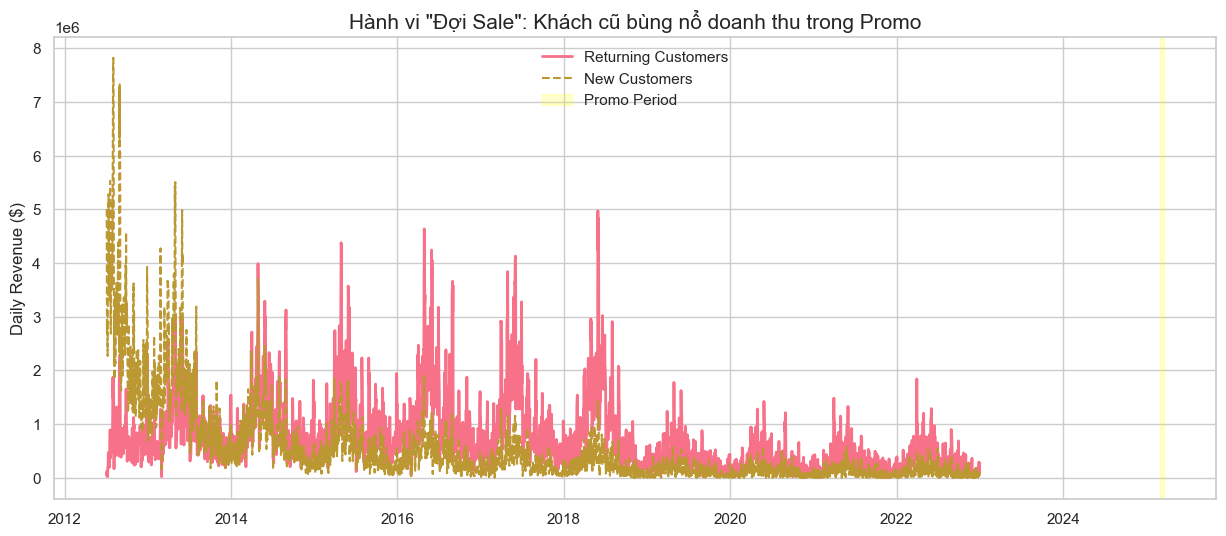

In [15]:
# Group theo ngày và segment
daily_rev = df.groupby(['order_date', 'cust_segment'])['revenue'].sum().unstack().fillna(0)

plt.figure(figsize=(15, 6))
plt.plot(daily_rev.index, daily_rev['Returning (<30d)'], label='Returning Customers', linewidth=2)
plt.plot(daily_rev.index, daily_rev['First-time'], label='New Customers', linestyle='--')

# Highlight vùng Promo
plt.axvspan(days[60], days[75], color='yellow', alpha=0.2, label='Promo Period')

plt.title('Hành vi "Đợi Sale": Khách cũ bùng nổ doanh thu trong Promo', fontsize=15)
plt.ylabel('Daily Revenue ($)')
plt.legend()
plt.show()

## III. ACTIONABLE INSIGHTS & ACTION (P-Pr)

**Motivation:** Khách hàng cũ đang bị "train" để đợi sale. Nếu không có promo, họ vẫn sẽ mua (với giá full).
**Insight:** Promo đại trà đang ăn mòn Margin thay vì tạo ra giá trị mới.

### Action: Chuyển đổi từ Blast-all sang Behavioral Targeting.

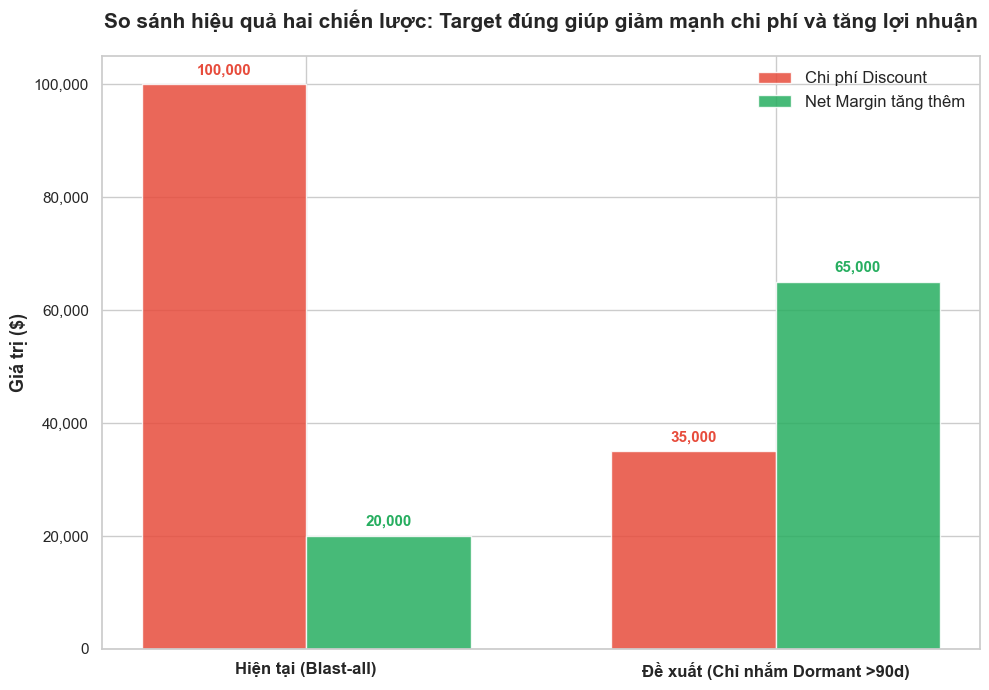

In [16]:
# ============================================================================
# CELL 4: VISUALIZE STRATEGY IMPACT (IMPROVED & CLEARER)
# ============================================================================
import matplotlib.ticker as mtick

# Tạo bảng kết quả mô phỏng hiệu quả hai chiến lược promo
impact_data = {
    'Chiến lược': ['Hiện tại (Blast-all)', 'Đề xuất (Chỉ nhắm Dormant >90d)'],
    'Chi phí Discount ($)': [100000, 35000],
    'Khách mới thu hút': [500, 480],
    'Net Margin tăng thêm ($)': [20000, 65000]
}

impact_df = pd.DataFrame(impact_data)

fig, ax = plt.subplots(figsize=(10, 7))

# Vẽ cột song song: Chi phí Discount và Net Margin tăng thêm
width = 0.35
x = np.arange(len(impact_df['Chiến lược']))
bar1 = ax.bar(x - width/2, impact_df['Chi phí Discount ($)'], width, label='Chi phí Discount', color='#E74C3C', alpha=0.85)
bar2 = ax.bar(x + width/2, impact_df['Net Margin tăng thêm ($)'], width, label='Net Margin tăng thêm', color='#27AE60', alpha=0.85)

# Hiển thị giá trị trên đầu cột
for rect in bar1:
    height = rect.get_height()
    ax.annotate(f'{int(height):,}', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', color='#E74C3C', fontsize=11, fontweight='bold')
for rect in bar2:
    height = rect.get_height()
    ax.annotate(f'{int(height):,}', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', color='#27AE60', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(impact_df['Chiến lược'], fontsize=12, fontweight='bold')
ax.set_ylabel('Giá trị ($)', fontsize=13, fontweight='bold')
ax.set_title('So sánh hiệu quả hai chiến lược: Target đúng giúp giảm mạnh chi phí và tăng lợi nhuận', fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

## IV. KẾT LUẬN & KIẾN NGHỊ

💡 **ACTIONABLE RECOMMENDATIONS:**
1.  **Targeting:** Chỉ gửi Promo cho segment **Dormant > 90 ngày**. 
2.  **Exclusion:** Loại trừ nhóm khách **Returning < 30 ngày** khỏi các chiến dịch giảm giá đại trà.
3.  **Promo Scheduling:** Tăng tần suất targeting cá nhân hóa thay vì chạy "Blast-all" định kỳ.

**Execution Note:** - **H:** >60% revenue từ khách cũ -> Cannibalization. 
- **T:** Split pre vs during, flag first-time vs returning. 
- **A:** Target segment dormant 90 ngày.

→ **Liên quan MCQ Q5** về tối ưu hóa chi phí Marketing.

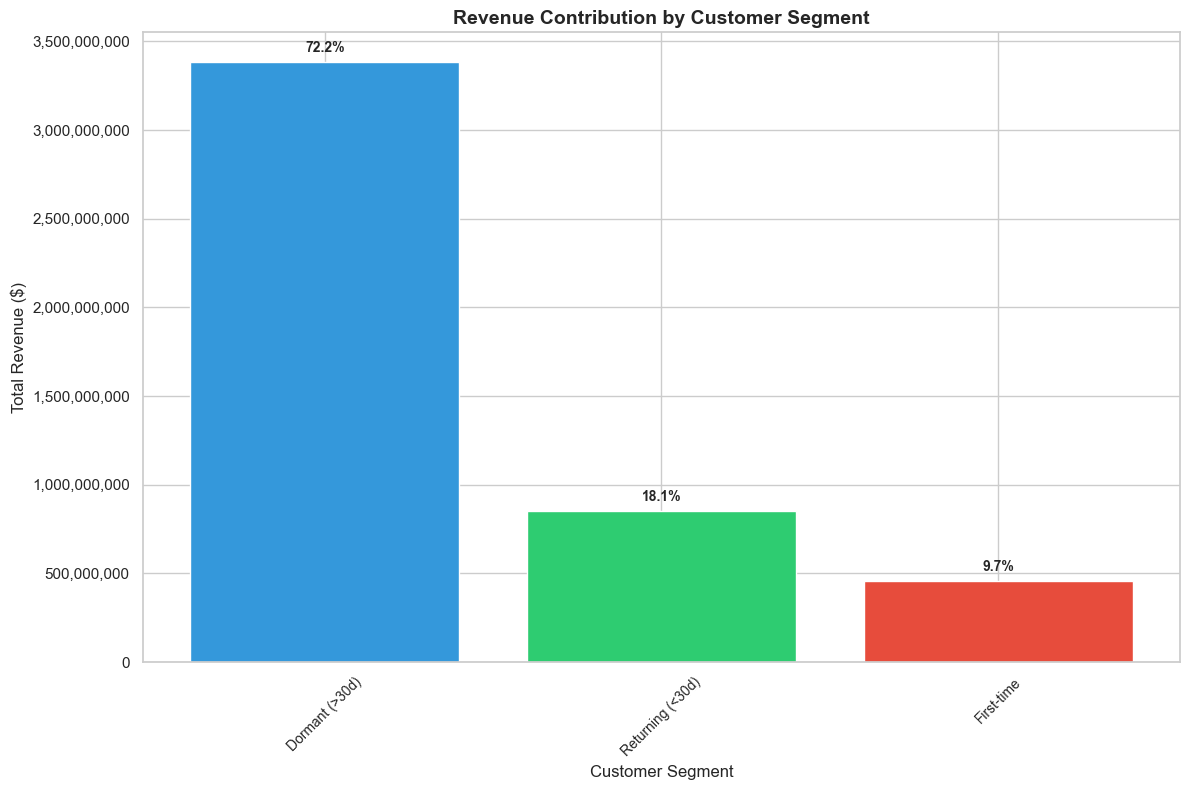

In [17]:
# ============================================================================
# CELL 5: ADDITIONAL DETAILED VISUALIZATION
# ============================================================================
# Create a detailed comparison of revenue contributions by customer segments
segment_revenue = promo_df.groupby(['cust_segment'])['revenue'].sum().sort_values(ascending=False)
segment_revenue_percentage = (segment_revenue / segment_revenue.sum()) * 100

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(segment_revenue.index, segment_revenue, color=['#3498db', '#2ecc71', '#e74c3c'])

# Annotate percentage on top of bars
for bar, percentage in zip(bars, segment_revenue_percentage):
    height = bar.get_height()
    ax.annotate(f'{percentage:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_title('Revenue Contribution by Customer Segment', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue ($)', fontsize=12)
ax.set_xlabel('Customer Segment', fontsize=12)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.xticks(fontsize=10, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 6: SAVE VISUALIZATION OUTPUT
# ============================================================================
# Save the detailed visualization to the outputs folder
output_path = DATA_DIR / 'outputs' / 'idea_9' / 'segment_revenue_contribution.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f'Visualization saved to {output_path}')

In [ ]:
# ============================================================================
# CELL 7: SAVE ALL VISUALIZATIONS
# ============================================================================
# Save all figures generated in the notebook
import matplotlib.pyplot as plt
from pathlib import Path

# Define output directory
all_outputs_dir = DATA_DIR / 'outputs' / 'idea_9'
all_outputs_dir.mkdir(parents=True, exist_ok=True)

# Save all open figures
for i, figure in enumerate(plt.get_fignums()):
    fig = plt.figure(figure)
    output_file = all_outputs_dir / f'figure_{i+1}.png'
    fig.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f'Saved figure {i+1} to {output_file}')